In [3]:
!pip install obspy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 17.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 60.5 MB/s eta 0:00:00
  Attempting uninstall: sqlalchemy
    Found existing installation: SQLAlchemy 2.0.37
    Uninstalling SQLAlchemy-2.0.37:
      Successfully uninstalled SQLAlchemy-2.0.37
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aext-project-filebrowser-server 4.1.0 requires sqlalchemy>=2.0.29, but you have sqlalchemy 1.4.54 which is incompatible.


In [5]:
# Imports
import os
import obspy
from obspy.clients.fdsn.mass_downloader import Restrictions, MassDownloader, GlobalDomain

seismogram_path = './data/seismograms' # Set download path
xml_path = './data/stations' # Set XML path

In [7]:
# Manually set start time, number of days of data to download, and station info
start_time = obspy.UTCDateTime(2012, 1, 1)
days_to_download = 4
network = "IU" 
station = "QSPA" # South Pole seismic station
location = "00"
channel = "BH?" # ? is a wildcard for all channels starting with BH

# Set up to download from IRIS, using global domain because we're specifying
# specific stations
mdl = MassDownloader(providers=['IRIS'])
domain = GlobalDomain()

SEC_PER_DAY = 24 * 3600

# Download four days of data in one day chunks
for day in range(days_to_download):
    end_time = start_time + SEC_PER_DAY
    restrictions = Restrictions(
        starttime=start_time,
        endtime=end_time,
        chunklength_in_sec=SEC_PER_DAY, #1 day chunks
        network=network,
        station=station,
        location=location,
        channel=channel,
        reject_channels_with_gaps=False,
        minimum_length=0.0,
        minimum_interstation_distance_in_m=100.0 # Guard against same station having different names
        )
    mdl.download(domain, restrictions, mseed_storage=seismogram_path,
                stationxml_storage=xml_path,)
   
    start_time += SEC_PER_DAY # Update to next day

# Running this cell results in a folder with 3 channels * 4 days = 12 mseed files
# and a metadata folder with 1 stationxml file.

[2025-06-23 12:06:33,522] - obspy.clients.fdsn.mass_downloader - INFO: Initializing FDSN client(s) for IRIS.
[2025-06-23 12:06:34,090] - obspy.clients.fdsn.mass_downloader - INFO: Successfully initialized 1 client(s): IRIS.
[2025-06-23 12:06:34,094] - obspy.clients.fdsn.mass_downloader - INFO: Total acquired or preexisting stations: 0
[2025-06-23 12:06:34,095] - obspy.clients.fdsn.mass_downloader - INFO: Client 'IRIS' - Requesting reliable availability.
[2025-06-23 12:06:34,345] - obspy.clients.fdsn.mass_downloader - INFO: Client 'IRIS' - Successfully requested availability (0.25 seconds)
[2025-06-23 12:06:34,346] - obspy.clients.fdsn.mass_downloader - INFO: Client 'IRIS' - Found 1 stations (3 channels).
[2025-06-23 12:06:34,347] - obspy.clients.fdsn.mass_downloader - INFO: Client 'IRIS' - Will attempt to download data from 1 stations.
[2025-06-23 12:06:34,348] - obspy.clients.fdsn.mass_downloader - INFO: Client 'IRIS' - Status for 3 time intervals/channels before downloading: NEEDS_DO

In [9]:
# Load seismograms
inv =  obspy.read_inventory("./data/stations/*")
stream = obspy.Stream()

for trace_index in range(days_to_download):
    st_index = trace_index * 3  # Each day has 3 channels
    ed_index = trace_index * 3 + 3 
    for file in os.listdir(seismogram_path)[st_index:ed_index]:
        # Each mseed file may contain multiple traces that need to be combined
        temp_stream = obspy.read(f'{seismogram_path}/{file}')
        temp_stream.attach_response(inv)
        t1 = temp_stream[0]
    
        for trace in temp_stream[1:]:
            t1 = t1.__add__(trace, method=1,fill_value=0)
        stream.append(t1)

# Seperate into North, South, and Vertical components
stream.sort()
N = stream.select(channel='BH1')
E = stream.select(channel='BH2')
Z = stream.select(channel='BHZ')

# Make daily streams
day_streams = []
for day in range(len(N)):
    day_stream = obspy.Stream(traces=[N[day],E[day],Z[day]])
    day_streams.append(day_stream)
        

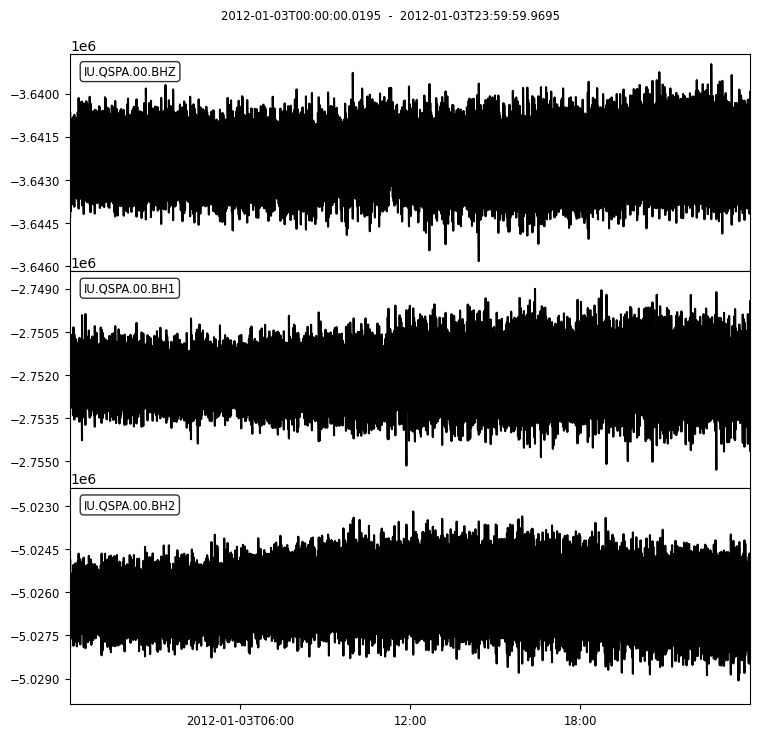

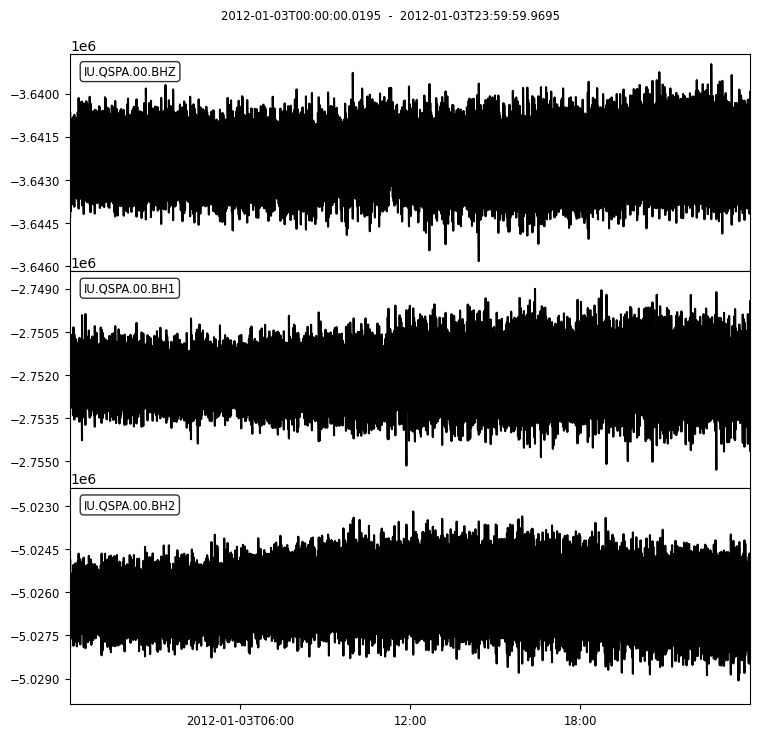

In [11]:
# Example plot - still looks like noise because we haven't filtered yet
day_streams[2].plot()

In [13]:
# Filter and crop to Whillans event
# 2012-01-02 09:21:15, grabbed from Event Start Time list. Could also find programmatically
whillans_event_time = obspy.UTCDateTime("2012-01-02T09:21:15")
# Filter and trim
filtered_days = []
for day_stream in day_streams:
        filtered = day_stream.copy() # Filtering and trimming is done 'in place'
        #filt.remove_response() # Expensive!
        filtered.filter("bandpass", freqmin=1/100,freqmax=1/30) # Freqmin freqmax from Pratt et al., 2014
        filtered.trim(starttime=whillans_event_time - 3600, endtime=whillans_event_time +3600)
        filtered_days.append(filtered)

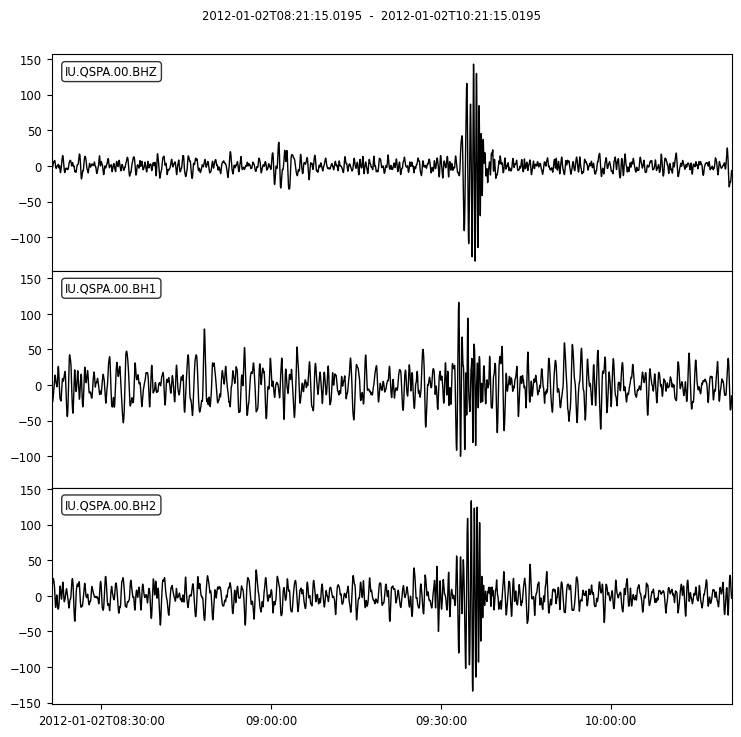

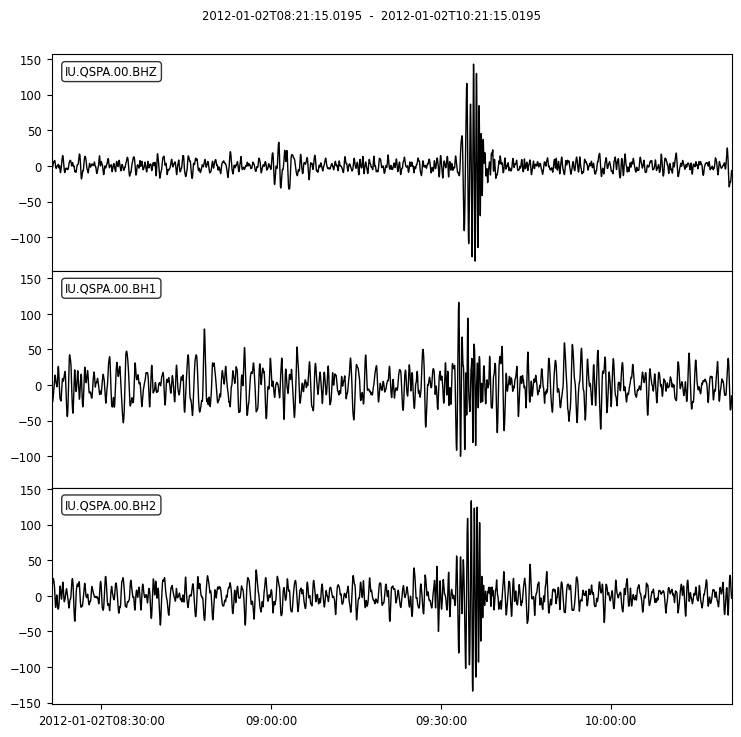

In [15]:
# Now we can see what is likely the event (cross check with earthquakes from USGS 
# to make sure not a teleseismic event https://earthquake.usgs.gov/earthquakes/search/)
filtered_days[1].plot()

# Can also extract for plotting in, e.g., matplotlib

In [ ]:
evts_path2 = "/Users/sambrown04/Documents/SURF/Events/2012_2012Events2stas"

df = my_lib.funcs.load_evt(evts_path2)
